In [5]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = ChatGroq(model="qwen/qwen3-32b")

In [43]:
from pydantic import BaseModel
from typing import Optional


class State(BaseModel):
    topic: Optional[str] = None
    story: Optional[str] = None
    improved_story: Optional[str] = None
    final_story: Optional[str] = None

In [44]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

## Nodes

def generate_story(state: State):
    msg = llm.invoke(f"Write a one sentence story premise on {state.topic}")
    return {"story": msg.content}

def check_conflict(state: State):
    if "?" in state.story or "!" in state.story:
        return "FAIL"
    else:
        return "PASS"

def improved_story(state: State):
    msg = llm.invoke(f"Enhance this story premise with vivid details: {state.story}")
    return {"improved_story": msg.content}

def polish_story(state: State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise: {state.improved_story}")
    return {"final_story": msg.content}

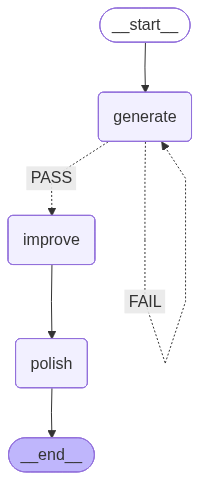

In [45]:
## Build the graph
graph_builder = StateGraph(State)

graph_builder.add_node("generate", generate_story)
graph_builder.add_node("improve", improved_story)
graph_builder.add_node("polish", polish_story)

## Define the edges
graph_builder.add_edge(START, "generate")
graph_builder.add_conditional_edges("generate", check_conflict, {"PASS": "improve", "FAIL": "generate"})
graph_builder.add_edge("improve", "polish")
graph_builder.add_edge("polish", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
state = {"topic": "Where there is a will there is a way"}
result = graph.invoke(state)

In [51]:
result

{'topic': 'Where there is a will there is a way',
 'story': '<think>\nOkay, the user wants a one-sentence story premise based on the proverb "Where there\'s a will, there\'s a way." Let me start by understanding the core message here. The proverb emphasizes determination and perseverance overcoming obstacles.\n\nSo, I need to create a story that embodies that. Maybe a protagonist facing significant challenges. Let me think about possible settings. Maybe a fantasy world where magic is involved, but there\'s a catch. The character needs to have a strong motivation. Perhaps they need to find a lost relative or achieve something important. \n\nWait, the user might want something original but relatable. Let me brainstorm. A young girl, maybe, who\'s determined to find her missing father. She has to navigate a dangerous, enchanted forest. The forest changes, so it\'s a moving target, which adds to the challenge. She uses her wits and resourcefulness, showing her determination. Each obstacle 